In [1]:
import requests
from IPython.core.display import HTML
# HTML(f"""
# <style>
# @import "https://cdn.jsdelivr.net/npm/bulma@0.9.4/css/bulma.min.css";
# </style>
# """)

# PCA for shape generation

**Mandatory assignment 2**
This is the second mandatory assignment, to be submitted on LearnIT as a Jupyter Notebook containing your implementation and notes by the deadline specified on [LearnIT](https://learnit.itu.dk/)
. Details on the submission process can be found [here](https://iml.itu.dk/01-about_the_course/01-AboutTheCourse.html)
.
This Assignment contains two parts. Part one is be feasible **after lecture 11**, and the second part **after lecture 12**.
The assignment applies PCA to generate face shapes. The objective is to explore the relationship between points in the latent space and their corresponding representations in the data space.


**Refresh**
The eigenvalue $\lambda_i$ is equal to the variance $\sigma_i^2$ along the direction of its eigenvector $v_i$. This equivalence allows us to use $\lambda_i$ and $\sigma_i^2$ interchangeably. Furthermore observe that the variance is given by $\sigma^2$ and hence the  standard deviation is given by $\sigma$ (standard deviation).
That is:

$$\lambda_i = \sigma_i^2$$
and therefore:

$$\sigma_i = \sqrt{\lambda_i}$$

<div style="float: none; width: 100%; justify-content: start" class="block is-clearfix">


<article class="message">
    <div class="message-body">
        <strong>Overview of mandatory tasks</strong>
        <ul style="list-style: none;">
            <li>
            <a href="#prep">Task 1: Data inspection</a>
            </li>
            <li>
            <a href="#get_pca">Task 2: Evaluate Principal compoenets</a>
            </li>
            <li>
            <a href="#gen">Task 3: Base face</a>
            </li>
            <li>
            <a href="#gen_reflect">Task 4: Base face reflections </a>
            </li>
            <li>
            <a href="#c">Task 5: Investigate variations in latent space</a>
            </li>
            <li>
            <a href="#interpolate">Task 6: Interpolation between two faces</a>
            </li>
            <li>
            <a href="#reflect">Task 7: Reflection</a>
            </li>
            <li>
            <a href="#correlation_eigen">Task 8: Eigenvalues and eigenvectors of correlat…</a>
            </li>
            <li>
            <a href="#Dimensionality_red">Task 9: Out of distribution generation</a>
            </li>
        </ul>
    </div>
</article>



</div>


**Important**
Solve the Introduction to PCA
 exercise part 1 **before starting on part 1 of this assignment**. 

# Part 1
## Data
The dataset used for the assigment consist of 120 landmarks (2D points) of faces (data space). A face consists of 73 (x,y)-coordinate pairs, i.e. 146 featues in total.

---
**Task 1 (easy): Data inspection👩‍💻**
1. Run the cell below to load libraries, the data and to  visualize the first 6 sample face shapes.


---

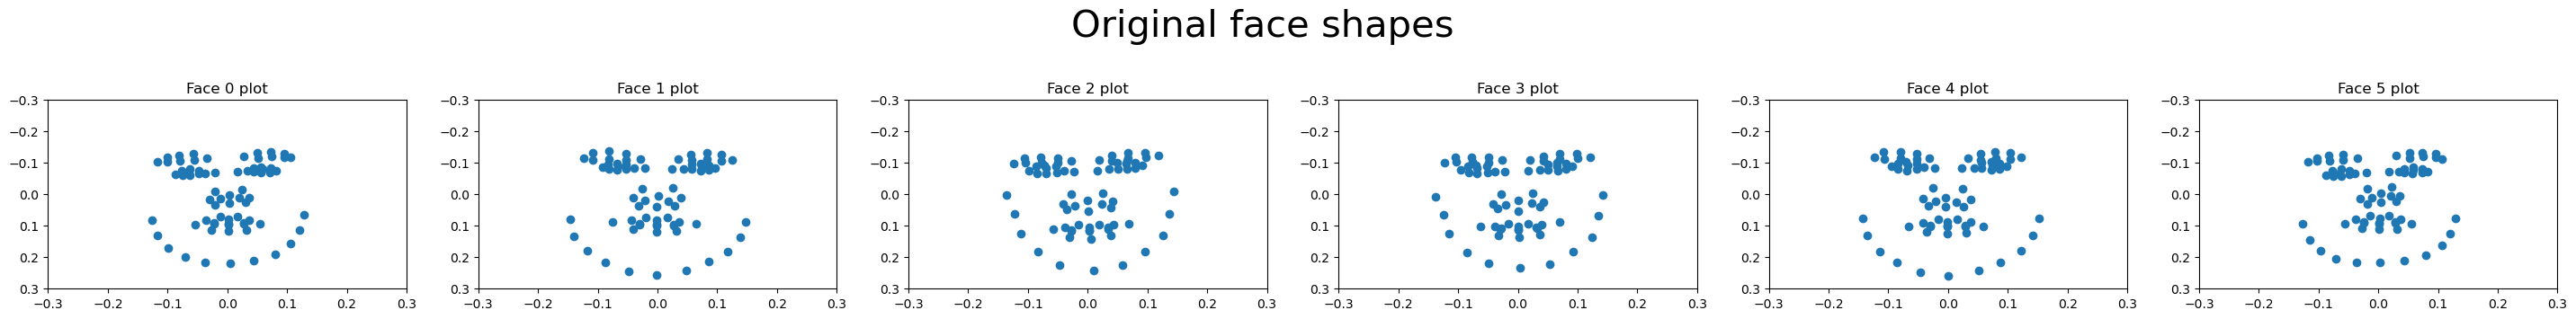

In [2]:
## Importing libraries
import matplotlib.pyplot as plt
import numpy as np
import scipy
from pca_utils import *
import os
from glob import glob

path = './db/'
shapes, _ = face_shape_data(path)

plot_many_faces(shapes[:6],"Original face shapes");

## PCA implementation
The following tasks are about using the implementation of PCA from the in-class exercise on the face shape dataset. 

---
**Task 2 (easy): Get principal compontents👩‍💻**
1. Complete the `get_principal_components`
 function so that it returns all principal components `comp`
, eigenvalues `val`
 and mean vector `mu`
, given the dataset `shapes`
.
2. Use the `get_principal_components`
 function to calculate the principal components (`comp`
) for the face dataset.
3. Implement the function `transform_to_latent_space`
  according to the comments in the cell below using  $\mathbf{a} = \mathbf{\Phi_k}^\top(\mathbf{x}-\mathbf{\mu})$ .
4. Implement the function `transform_from_latent_space`
  according to the comments in the cell below using $x  = \mathbf{\Phi_k} \mathbf{a} + \mathbf{\mu}$ . 
5. Run the cell below to map $6$ face shapes to the latent space and back to the original data space. The `plot_many_faces`
 function is used to display both the original and the restored face shapes.
6. Visually inspect the figures and describe the reconstruction error.


---

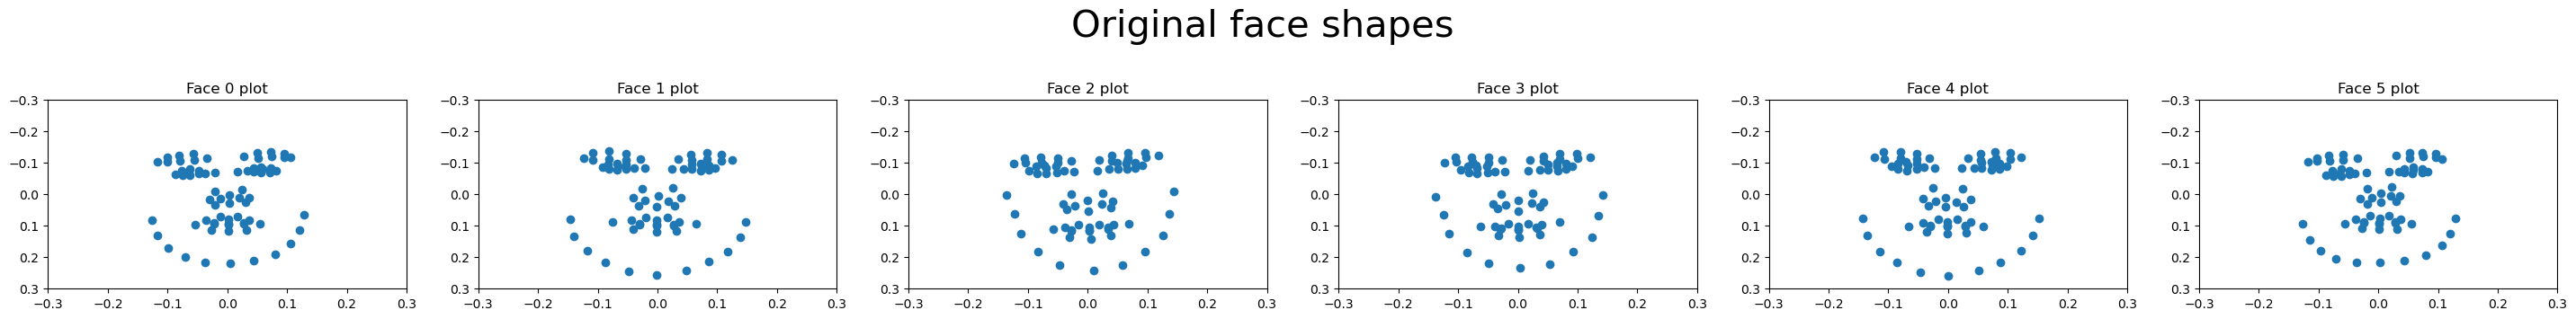

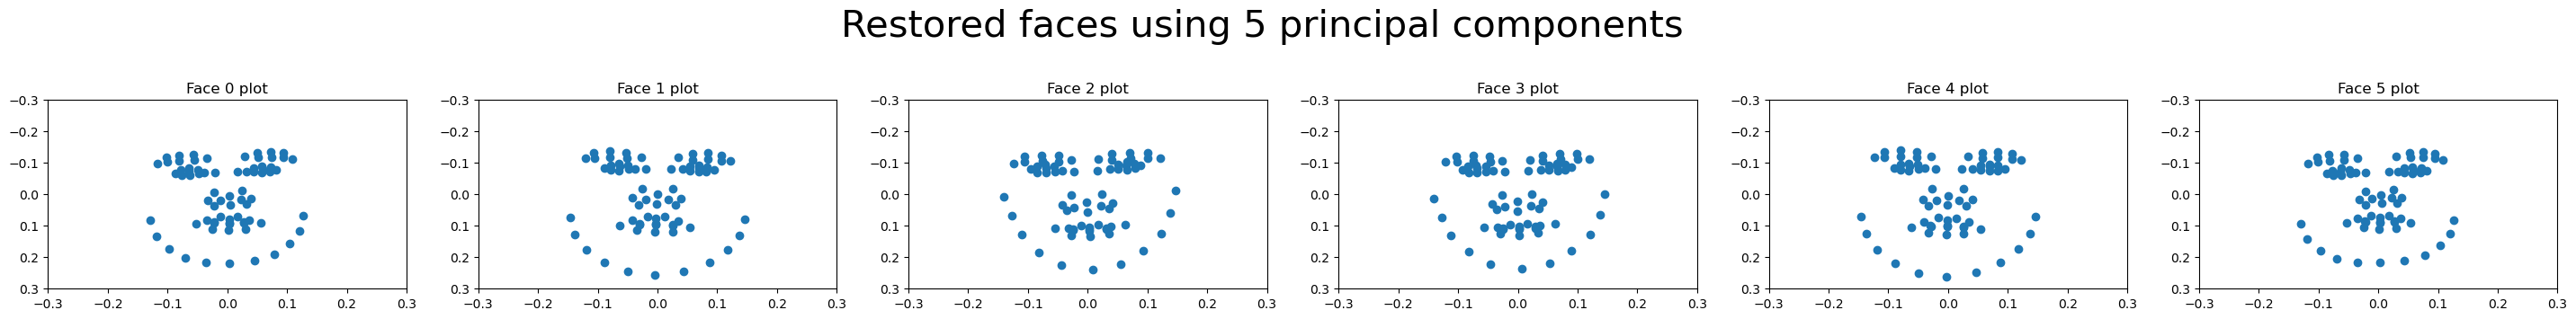

In [3]:
# 1
def get_principal_components(X):
    """Calculates principle components for X.

    Args:
        X: The dataset. An NxD array were N are the number of samples and D are
        the number of features.

    Returns:
        Tuple (components, eigenvalues, mu) where components is a DxD matrix of
        principle components, eigenvalues is a D-element vector of
        corresponding eigenvalues, and mu is a D-element array containing the mean
        vector.
    """
    # Copy your PCA implementation to here.

    # Compute the mean vector
    mu = np.mean(X, axis=0) # an array of the mean for each feature (column)

    # Compute the covariance matrix
    cov = np.cov(X-mu, rowvar=False) # mean is subtracted to center the data
    # Perform eigen decomposition
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    # Sort eigenvalues and eigenvectors in descending order
    # np.argsort(eigenvalues) returns the indices that would sort eigenvalues in ascending order. 
    # [::-1] reverses that array, so sorted_indices gives indices that order eigenvalues descending.
    sorted_indices = np.argsort(eigenvalues)[::-1] 
    # reorder the eigenvalues so its entries are in descending order.
    eigenvalues = eigenvalues[sorted_indices]
    # reorder the eigenvector matrix to match that descending order. 
    components = eigenvectors[:, sorted_indices]

    return components, eigenvalues, mu


# 2, 3 and 4
# Get the principal components for the dataset and transform the faces to feature space.
comp, val, mu = get_principal_components(shapes)

# write code for finding the cumulative proportional variance here

# selecting 5 components 
n_components = 5


# 5
def transform_to_latent_space(X, principle_components, mu):
    """Transforms X to an k-dimensional space where k is the number of
    principle_components.

    Args:
        X: The dataset. An NxD array were N are the number of samples and D are
        the number of features.
        principle_components: An Dxk matrix containing the principle
        components.
        mu: A D-element array containing the mean vector.

    Returns:
        A Nxk array describing the transformed data.
    """
    # from PCA implementation
    X_N, X_D = X.shape
    comp_D, comp_k = principle_components.shape
    assert X_D == comp_D, ("Dimension mismatch between X and principle_components", "X:", X_D, "comp:" , comp_D)
    mu_len = len(mu)
    assert X_D == mu_len, ("Dimension mismatch between X and mu", "X:", X_D, "mu:" , mu_len)

    phi = principle_components # D x k
    X_centered = X - mu # N x D
    a = X_centered @ phi # N x k
    # OBS In the formula for ´a´ above, a is computed as phi.T @ (X - mu), but we do it differently here.
    # This is because X, in our case, is stored row-wise, i.e., each row is a datapoint, whereas the formula assumes column-wise storage (and same goes for mu, since it was made from X).
    # And because we want a to be row-wise (each row a datapoint) aswell, whereas the formula assumes column-wise storage.
    # At least this is our interpretation. But we would like more clarification on this, since we can not make it fit with the describtions of the formulas dimentions.
    assert a.shape == (X_N, comp_k), ("Output shape mismatch", "Expected:", (X_N, comp_k), "Got:", a.shape)
    return a

    
# 6  
def transform_from_latent_space(v, principle_components, mu):
    """Reverses the dimensionality reduction of v, a Nxk matrix where
    k is the number of principle components. The result is a NxM matrix.

    Args:
        v: The transformed dataset with size Nxk.
        principle_components: An Dxk matrix containing the principle
        components.
        mu: A Mx1 matrix containing the mean vector.

    Returns:
        An NxD array reconstruction of the original feature vectors X.
    """
    # from PCA implementation
    a = v # N x k
    phi = principle_components # D x k
    x = (a @ phi.T) + mu # N x D
    # OBS In the formula for ´x´ above, x is computed as (phi @ a) + mu, but we do it differently here.
    # That is because we want x to be row-wise (each row a datapoint), whereas the formula assumes column-wise storage.
    # At least this is our interpretation. But we would like more clarification on this, since we can not make it fit with the describtions of the formulas dimentions.
    return x

    
# 7     
used = comp[:, :n_components]

# transforming and reconstructing the 6 first faces in the dataset
plot_many_faces(shapes[:6],"Original face shapes")
transformed = transform_to_latent_space(shapes[:6], used, mu)
restored = transform_from_latent_space(transformed, used, mu)
plot_many_faces(restored,"Restored faces using 5 principal components")


# Inspection of reconstruction error plot
# The reconstructed faces still look quite similar to the original faces, but some details are lost.
# E.g. face 4 has a noticible difference with eyebrows looking a bit less tilted 
# and face 2 and 3 have kind of sharp edges around the chin in the original data, but in the reconstructed faces these edges are more rounded. 


---
**Task 3 (easy): Evaluate Principal compoenets💡**
1. How many components are needed to retain $50\%$, $60\%$, $80\%$, $95\%$ of the total variation?
2. Seting $k=5$ components. How much of the total variance is retained?
3. Visually inspect the figures and describe the reconstruction error.


---

In [4]:
#Write your reflections here...
# 1

def components_for_variance(pc_values, variance_percent):
    """Calculates the minimum number of principal components required to
    retain a given amount of variance.

    Args:
        pc_values: A D-element vector of eigenvalues.
        variance_percent: The desired amount of variance to retain (a float in
        the range [0, 1]).

    Returns:
        The minimum number of principal components required to retain the
        desired amount of variance.
    """
    assert 0 <= variance_percent <= 1, "variance_percent must be in the range [0, 1]"


    # Calculate total variance, cumulative variance, and individual variance proportions
    total = np.sum(pc_values)
    cumulative = np.cumsum(pc_values)
    proportion = cumulative / total

    # Find the minimum number of components required to reach the desired cumulative variance
    pc_idx = np.argwhere(proportion >= variance_percent - 1e-7)[0, 0] # -1e-7 to avoid floating point issues

    return pc_idx + 1  # +1 because indices start at 0

# 50% variance:
num_components_50 = components_for_variance(val, 0.5)
print("Number of components for 50% variance:", num_components_50)
# 60% variance:
num_components_60 = components_for_variance(val, 0.6)
print("Number of components for 60% variance:", num_components_60)
# 80% variance:
num_components_80 = components_for_variance(val, 0.8)
print("Number of components for 80% variance:", num_components_80)
# 95% variance:
num_components_95 = components_for_variance(val, 0.95)
print("Number of components for 95% variance:", num_components_95)

Number of components for 50% variance: 2
Number of components for 60% variance: 2
Number of components for 80% variance: 4
Number of components for 95% variance: 8



**Important**
Solve the Introduction to PCA
 exercise part 2 **before starting on part 2 of this assignment**. 

# Part 2
## Using PCA for shape generation
The principal components can be used to generate new samples $\mathbf{x}$ in data space by transforming a point in latent space according to 
$$\mathbf{x} = \Phi_{k} a + \mu$$
 where $\Phi_{k}$ is the matrix of k eigenvectors, $\mathbf{a}\in\mathbb{R}^{k}$ is a vector in latent space, and $\mu\in\mathbb{R}^{D}$ is the mean vector of the original data features in  the data space.

$$

{\Phi_k} = \begin{bmatrix} | & | & & | \\ {v}_1 & {v}_2 & \cdots & {v}_k \\ | & | & & | \end{bmatrix}

$$
The variance of the data in a given direction can be used to constrain the values of the elements of the vector $\mathbf{a}$ in latent space, assuming that the data follows a (multivariate) normal distribution. In a multivariate normal distribution each direction $v_i$ is also normally distributed. Each element $a_i$ can be constrained to be within the observed variance in direction $v_i$. The variance $\sigma_i^2$ in the direction of $v_i$ is given by the eigenvalue $\lambda_i$, so the standard deviation is  $\sigma_i = \sqrt{\lambda_i}$.
In a 1D normal distribution (with mean $\mu$ and standard deviation $\sigma$), the area under the Gaussian curve between $\pm 3\sigma$ contains $99.7\%$ of the data (see [Figure 1](#normal) ). Thus, constraining each element $a_i$ to the interval $[-3\sigma_i, 3\sigma_i]$ will cover $99.7\%$ of the variance in the direction of $v_i$. 
<div class="has-text-centered">
<figure class="image is-inline-block" id="normal">

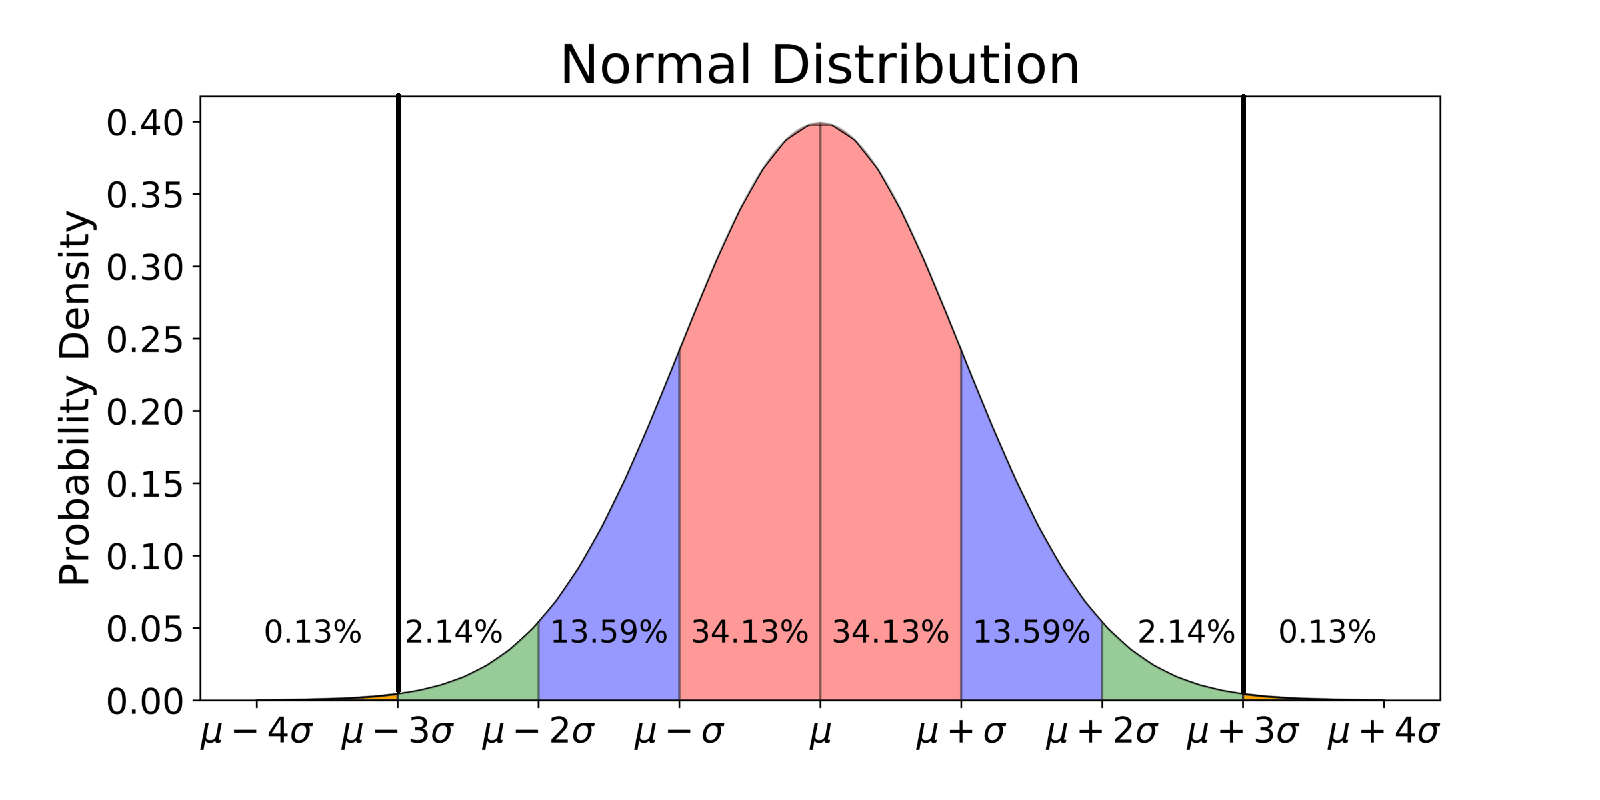

<figcaption class="figure-caption has-text-centered">Figure 1: Illustration of a normal distribution. The vertical lines mark the region covering $99.7\%$ of the variance. The shaded regions indicate the
area of the distribution covered by 1, 2, 3, and 4, standard deviations
($\sigma$) respectively.
</figcaption>
</figure>
</div>

---
**Task 4 (medium): Base face👩‍💻**
1. **Generate vectors:** run the cell below to create the zero vector in latent space, i.e. $\mathbf{a} = [0, 0, \dots, 0]\in\mathbb{R}^5$.
2. **Shape generation:** use $\mathbf{x} = \mathbf{\Phi} \mathbf{a} + \mathbf{\mu}$ to generate a face (vector in real space) from the vector $\mathbf{a}$. Use the `plot_face`
 function to visualise the generated face.
3. Change the elements of $\mathbf{a}$ to the values below, where $\lambda_i$ is the i-th eigenvalue and plot the resulting shapes for each modification:    
    - $\mathbf{a} = [\sqrt{\lambda_1},0, 0, 0, 0]$ $\in\mathbb{R}^5$? 
    - $\mathbf{a} = [0,-3\sqrt{\lambda_2}, 0, 0, 0]$ $\in\mathbb{R}^5$?




---

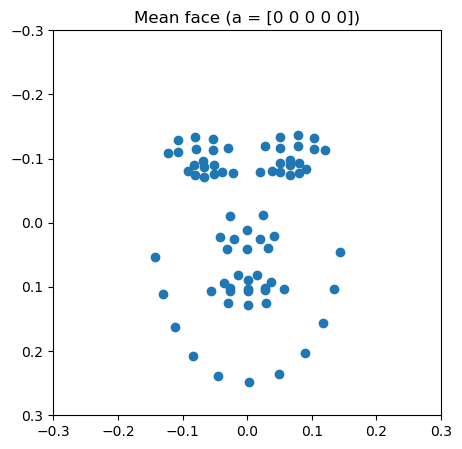

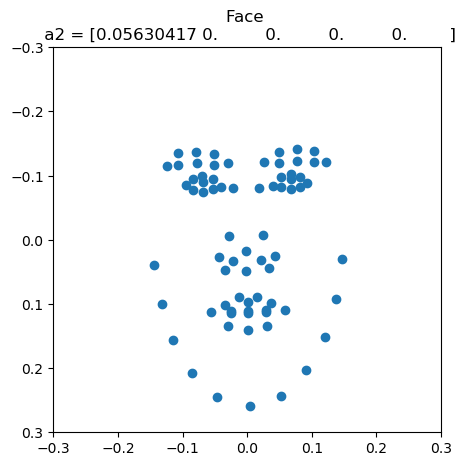

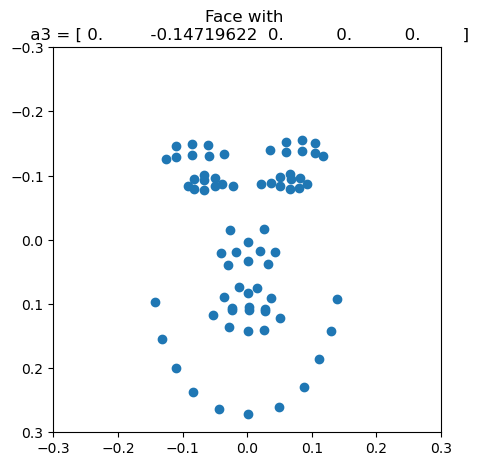

In [ ]:
a = np.array([0,0,0,0,0])

# Write your implementation here.
# 2 
face = transform_from_latent_space(a, comp[:, :5], mu) # we use first 5 components since the latent space is 5-dimensional.

plot_face(face)
plt.title(f"Mean face (a = {a})")
plt.show()

# 3
a2 = np.array([np.sqrt(val[0]),0,0,0,0]) # vary first component by 1 standard deviation
a3 = np.array([0,-3*np.sqrt(val[1]),0,0,0]) # vary second component by -3 standard deviations


face2 = transform_from_latent_space(a2, comp[:, :5], mu)
face3 = transform_from_latent_space(a3, comp[:, :5], mu)

plot_face(face2)
plt.title(f"Face \n a2 = {a2}")
plt.show()

plot_face(face3)
plt.title(f"Face with \n a3 = {a3}")
plt.show()


---
**Task 5 (medium): Base face reflections 💡**
1. Use $\mathbf{x} = \Phi_{k} a + \mu$ to explain what the vector $a \in R^5$ represents if     
    - $\mathbf{a}= [0,0,0,0,0]$?
    - $\mathbf{a} = [\sqrt{\lambda_1},0, 0, 0, 0]$? 
    - $\mathbf{a} = [0,-3\sqrt{\lambda_2}, 0, 0, 0]$?


2. Describe what face is generated and why.


---

In [ ]:
# Write your reflections here
# The vector a = [0, 0, ..., 0] in latent space corresponds to the mean face shape when transformed back to original space.
# This is because when we multiply the principal components by the zero vector and add the mean vector, we simply get the mean vector itself. 
# Therefore, the generated face will be the average of all faces in the dataset.

# The vector a = [sqrt(lambda_1), 0, 0, 0, 0] represents a face that deviates from the mean face shape along the direction of the first principal component by an amount equal to the square root of the first eigenvalue (lambda_1).
# This means that the generated face will exhibit the most significant variation present in the dataset, as the first principal component captures the largest variance.
# Increasing the first element of a does not mean that the difference itself is very different from the mean face (this depends on how large lambda_1 is), but rather that it represents the parameter which has the most variation in the whole dataset. 
# We tried to play a little bit around with different values for the first element of a, and our intepretation was that it might be related to how tilted the face is (if the person is looking up or down), but we are not completely sure about this.

# The vector a = [0, -3*sqrt(lambda_2), 0, 0, 0] represents a face that deviates from the mean face shape along the direction of the second principal component by an amount equal to -3 times the square root of the second eigenvalue (lambda_2).
# This means that the generated face will exhibit variation corresponding to the second most significant mode of variation in the dataset.
# Our interpretation of the plots was that this parameter might be related to the lip thickness, mouth shape or face length (maybe how "long" the face is).



## Investigating principal components
The following tasks are about investigating properties of principal components.

---
**Task 6 (medium): Investigate variations in latent space👩‍💻**
1. **Varying the 1st component:** Let $\mathbf{a} \in \mathbb{R^5}$ be a vector in the latent space. Generate 5 different vectors where only the first element, $a_1$, varies, while the remaining elements, $a_2, a_3, a_4, a_5$, are set to 0. Use `np.linspace`
 to generate 5 evenly spaced values for $a_1$ in the interval $[-3\sigma_1, 3\sigma_1]$. For each value of $a_1$, generate a corresponding face and display all 5 faces in a plot. 

2. **More components:** Do the same for each of the remaining four components, i.e. $a_2$-$a_5$ leaving the others as 0. 

3. **Component analysis:** Describe how each principal component changes the face shape (for example, the first component may change the length of the face). 



---

[[-0.16891252  0.          0.          0.          0.        ]
 [-0.08445626  0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.        ]
 [ 0.08445626  0.          0.          0.          0.        ]
 [ 0.16891252  0.          0.          0.          0.        ]]


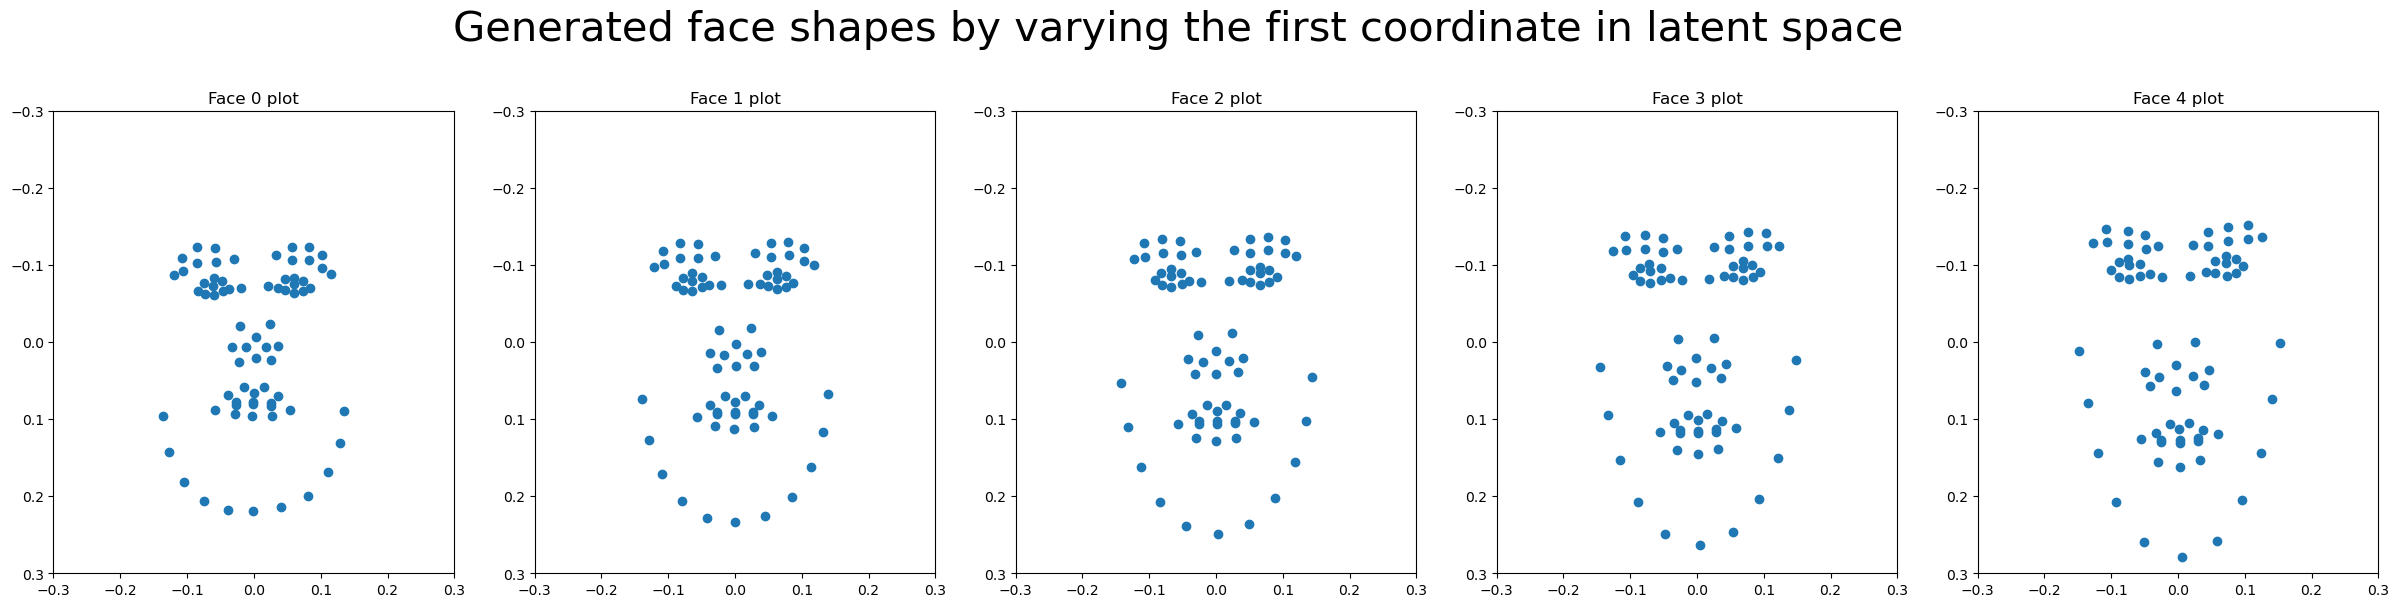

[[ 0.         -0.14719622  0.          0.          0.        ]
 [ 0.         -0.07359811  0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.        ]
 [ 0.          0.07359811  0.          0.          0.        ]
 [ 0.          0.14719622  0.          0.          0.        ]]


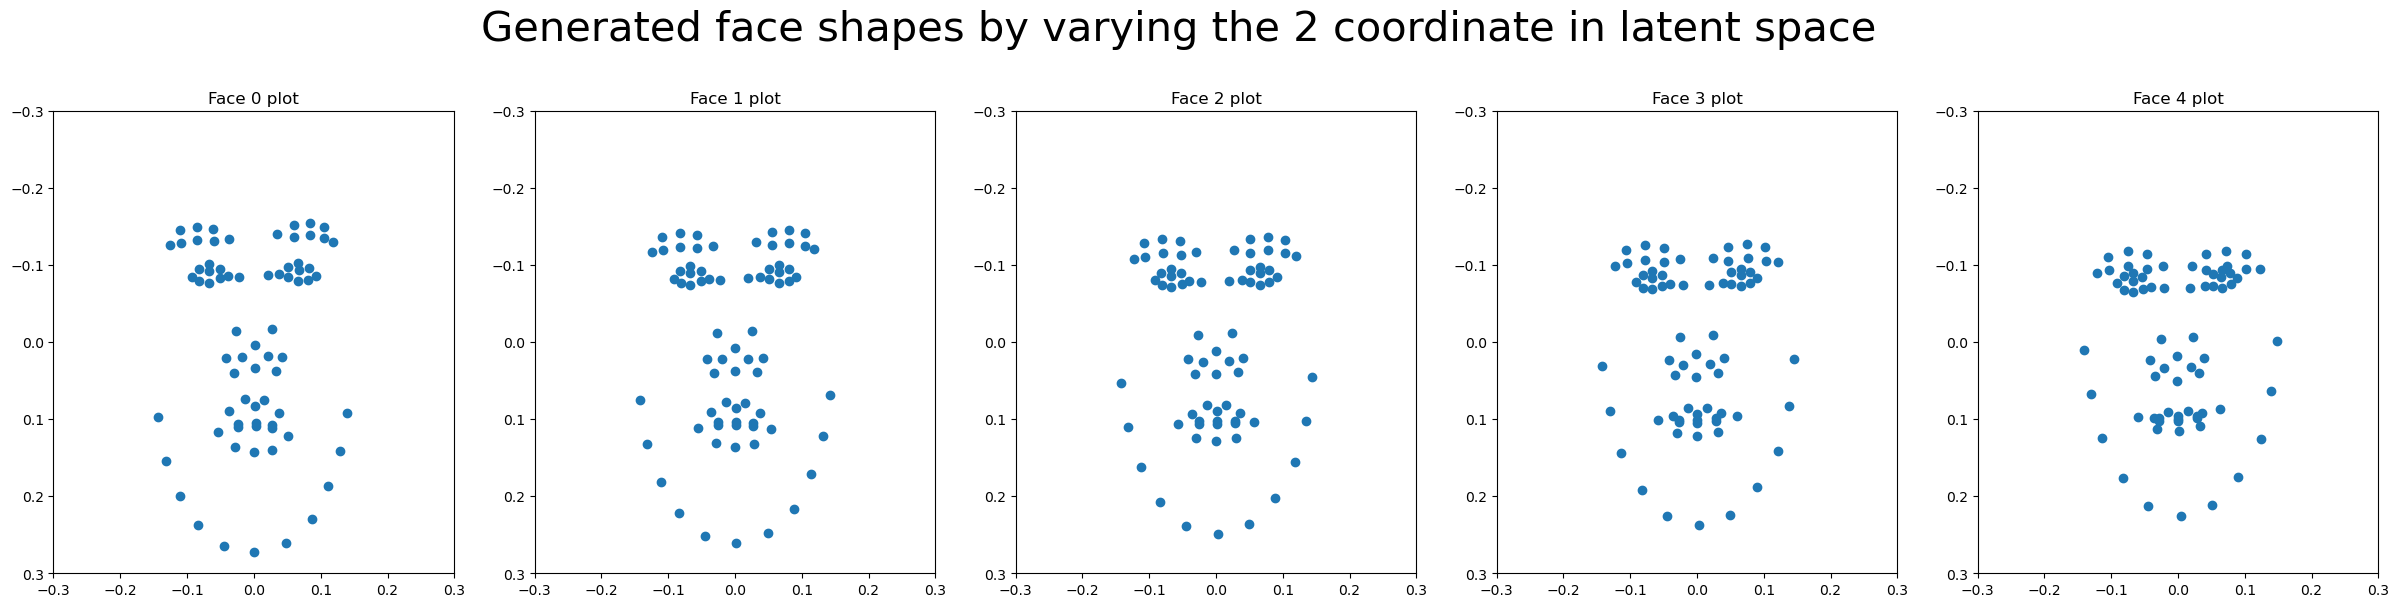

[[ 0.          0.         -0.09229026  0.          0.        ]
 [ 0.          0.         -0.04614513  0.          0.        ]
 [ 0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.04614513  0.          0.        ]
 [ 0.          0.          0.09229026  0.          0.        ]]


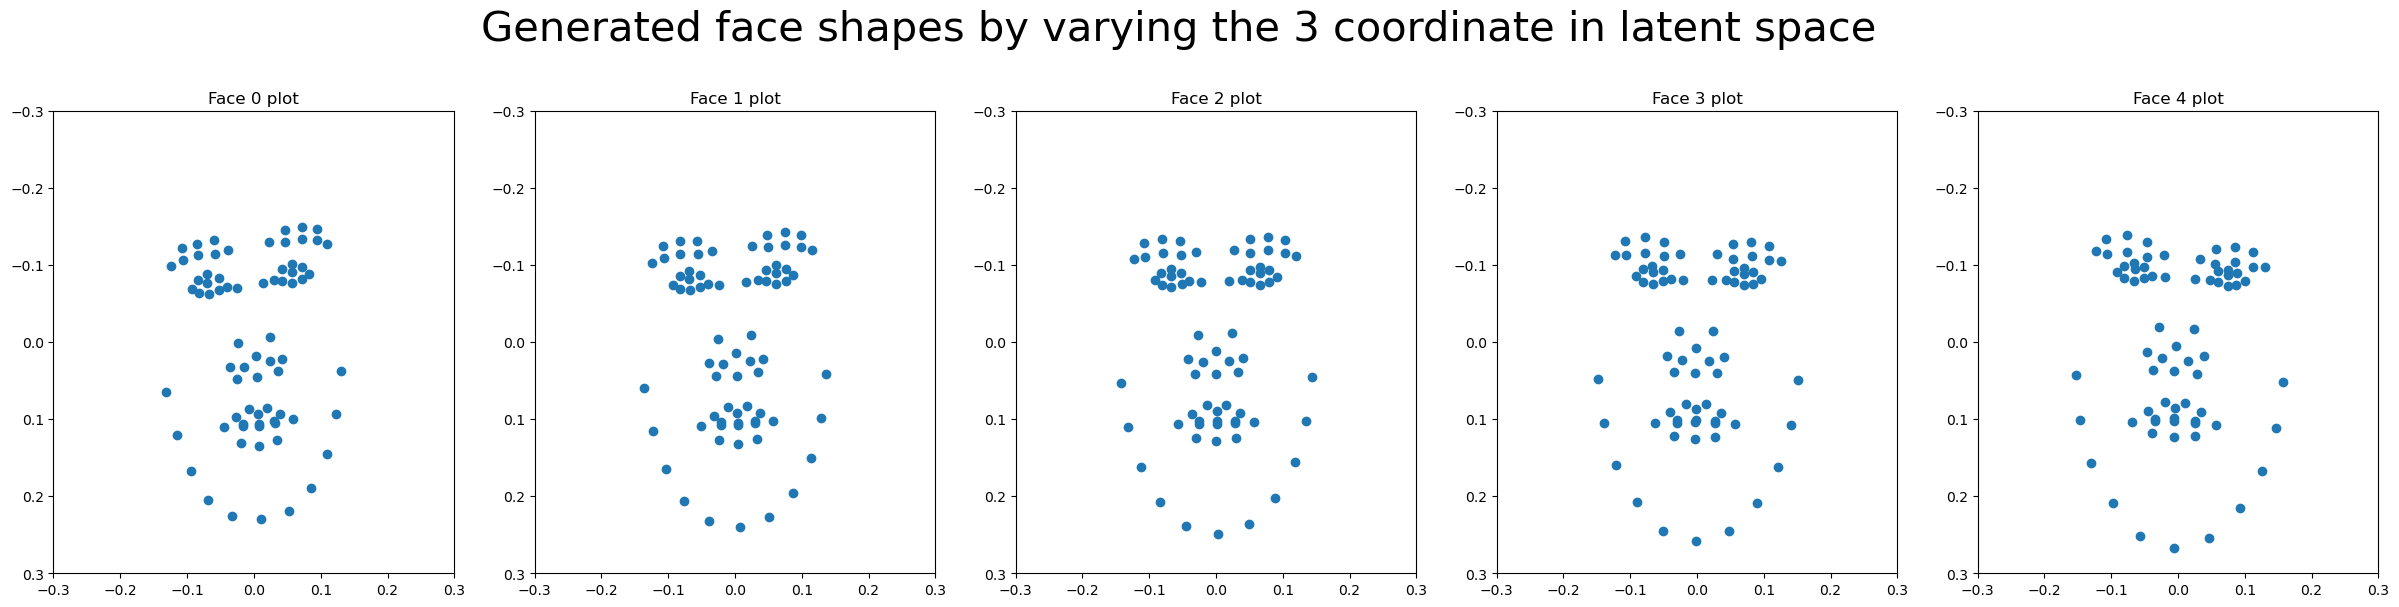

[[ 0.          0.          0.         -0.07311137  0.        ]
 [ 0.          0.          0.         -0.03655568  0.        ]
 [ 0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.03655568  0.        ]
 [ 0.          0.          0.          0.07311137  0.        ]]


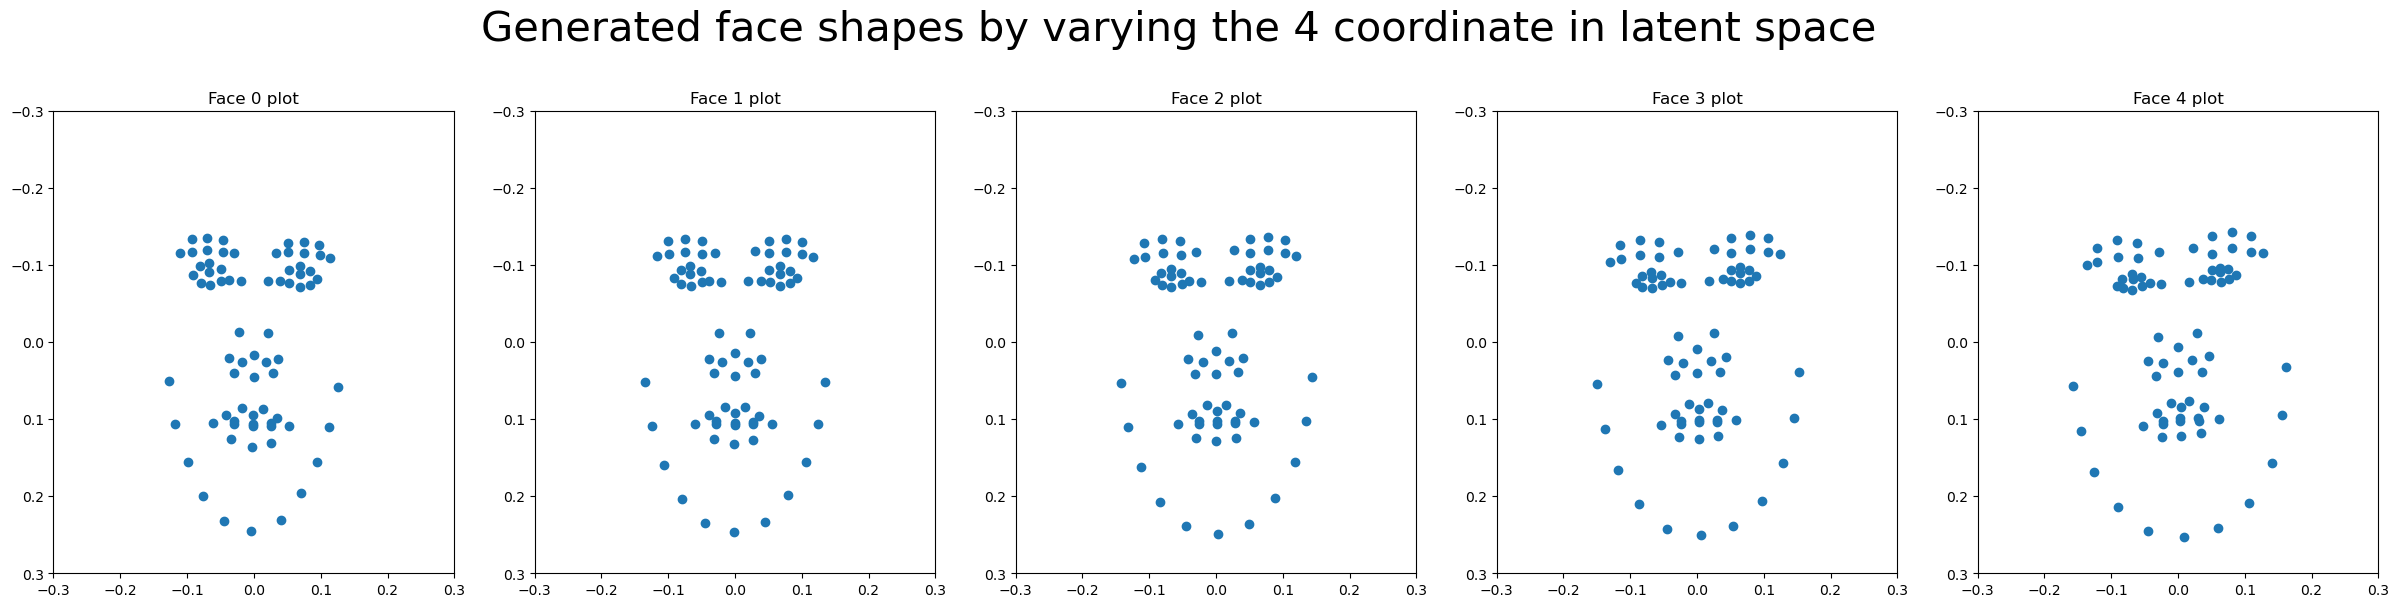

[[ 0.          0.          0.          0.         -0.05955704]
 [ 0.          0.          0.          0.         -0.02977852]
 [ 0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.02977852]
 [ 0.          0.          0.          0.          0.05955704]]


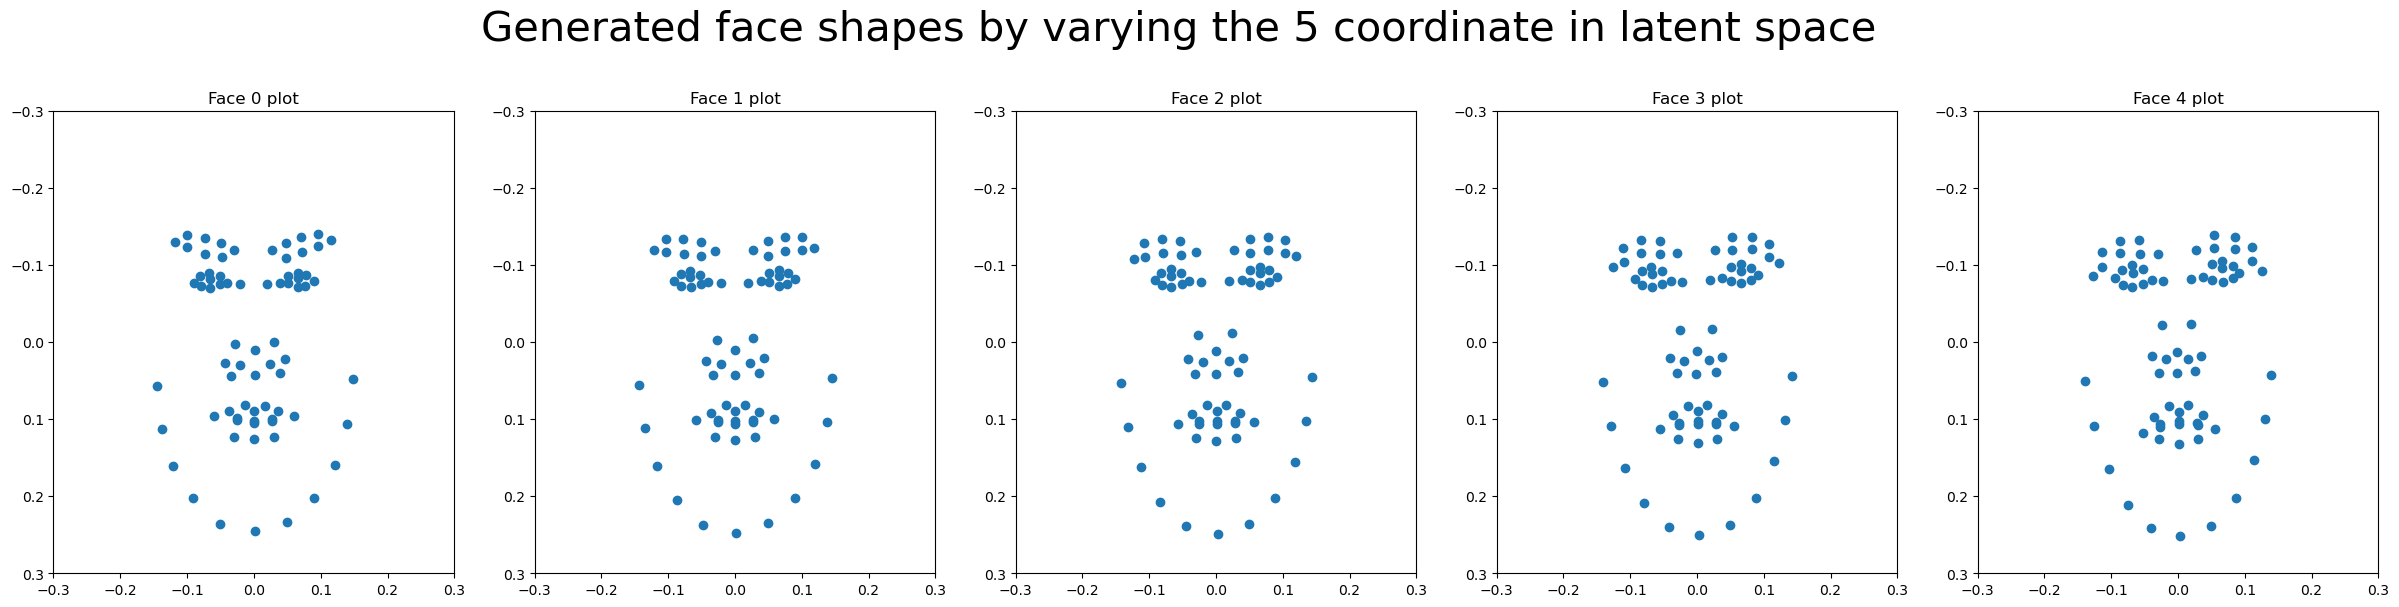

In [16]:
std_1 = np.sqrt(val[0]) # std/eigvalue for the first PC
np.linspace(-3*std_1, 3*std_1, num=5)

# Write your solution here
def vary_single_component_and_plot_faces(eigenvals, index):
    std = np.sqrt(eigenvals[index]) # variance for the given PC

    a = np.zeros((5, 5), dtype=float) # start with zero vectors
    for i, val in enumerate(np.linspace(-3*std, 3*std, num=5)):
        a[i,index] = val
    print(a)
    gen_shapes = transform_from_latent_space(a, comp[:, :5], mu)
    plot_many_faces(gen_shapes,f"Generated face shapes by varying the {index+1} coordinate in latent space")


# 1
a = np.array([[i,0,0,0,0] for i in np.linspace(-3*std_1, 3*std_1, num=5)]) # create a 5x5 array where we vary the first coordinate from -3*std_1 to 3*std_1, and keep the rest 0.
print(a)
gen_shapes = transform_from_latent_space(a, comp[:, :5], mu)
plot_many_faces(gen_shapes,"Generated face shapes by varying the first coordinate in latent space")

# 2
vary_single_component_and_plot_faces(val, 1)
vary_single_component_and_plot_faces(val, 2)
vary_single_component_and_plot_faces(val, 3)
vary_single_component_and_plot_faces(val, 4)



In [39]:
# Write your reflections here
# 3 
# - The first component seems to be related to the tilt of the face (tilting up or down). Maybe something with face length as well.
# - The second component might be related to the lip thickness, mouth shape (open -> closed (smiling)), or face length (maybe how "long" the face is).
# - The third component seems related to sideways tilt of the face (tilting left or right).
# - The fourth component seems related to face width (slim -> broad)
# - The fifth component seems related to eyebrow shape (straight -> curved down)

def retained_variance_for_components(pc_values, index):
    """Calculates the variance for a given index of principal components.

    Args:
        pc_values: A D-element vector of eigenvalues.
        index: The index of the principal component (0-based).

    Returns:
        The amount of variance out of the total variance explained by the specific principal component at the given index.
    """
    assert 0 <= index < len(pc_values), "index must be in the range [0, number of components - 1]"

    # Calculate total variance, cumulative variance, and individual variance proportions
    total = np.sum(pc_values)
    proportion = pc_values / total

    return proportion[index]  # -1 because indices start at 0

print("Variance explained by component 1:", retained_variance_for_components(val, 0))
print("Variance explained by component 2:", retained_variance_for_components(val, 1))
print("Variance explained by component 3:", retained_variance_for_components(val, 2))
print("Variance explained by component 4:", retained_variance_for_components(val, 3))
print("Variance explained by component 5:", retained_variance_for_components(val, 4))

# Above we computed the variance for each of the first 5 components.
# We clearly see that the first two components explain much more variance than the later components.

Variance explained by component 1: 0.368930695478732
Variance explained by component 2: 0.2801653321088853
Variance explained by component 3: 0.11013690543096992
Variance explained by component 4: 0.06911796084796205
Variance explained by component 5: 0.045865629379760305


## Interpolating between shapes
The following example shows how to interpolate two vectors.


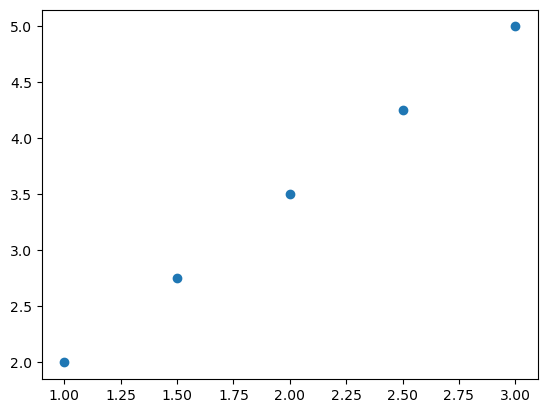

In [40]:
# #Template for doing interpolation between two (2D)- points 
d = np.linspace(np.array([1, 2]), np.array([3, 5]), num=5)
plt.scatter(d[:, 0], d[:, 1])


---
**Task 7 (medium): Interpolation between two faces👩‍💻**
**Shape Interpolation:**
1. Select points $\mathbf{a}$ and $\mathbf{b}$ in latent space (paying attention to the Gaussian constraints) and generate the faces.
2. Use `np.linspace`
 to generate 6 evenly spaced points that interpolate between two vectors, $\mathbf{a}$ and $\mathbf{b}$, in the latent space. Plot the resulting faces. 
3. Select $\mathbf{a}$ and $\mathbf{b}$ such that:    
    - $\mathbf{a}$ = $[-3\lambda_1,0,-3\lambda_3,0,0]$ and $\mathbf{b}$ = $[3\lambda_1,0,3\lambda_3,0,0]$.
    - $\mathbf{a}$ = $[0,5\lambda_2,0,0,0]$ and $\mathbf{b}$ = $[0,-5\lambda_2,0,0,0]$.
    - the generated shapes represent a smile.




---

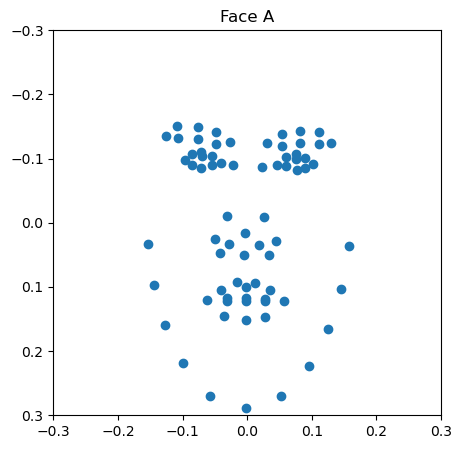

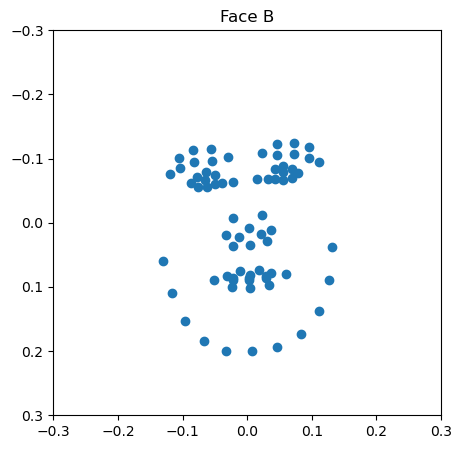

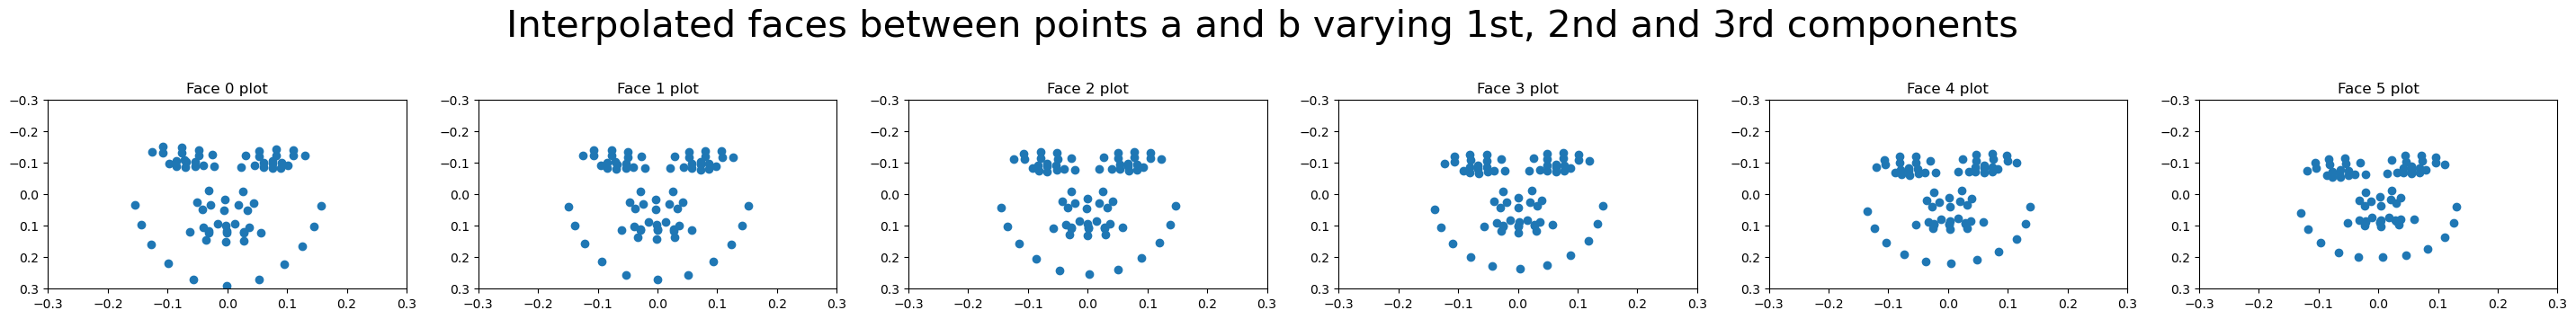

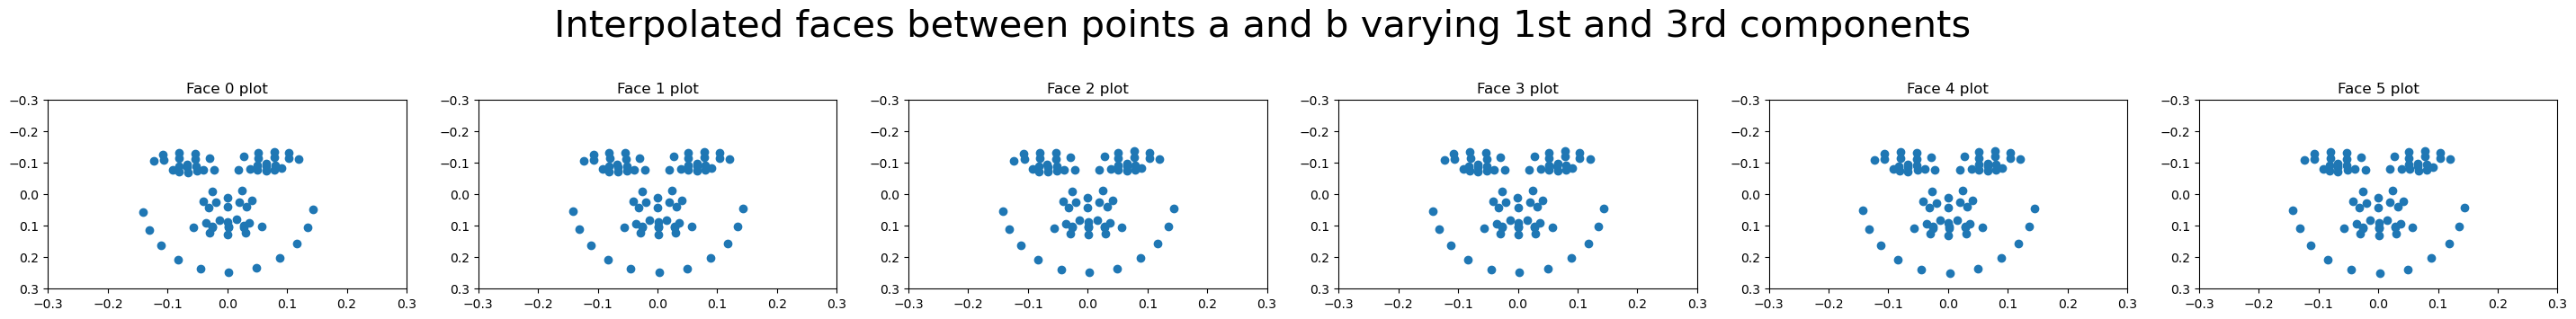

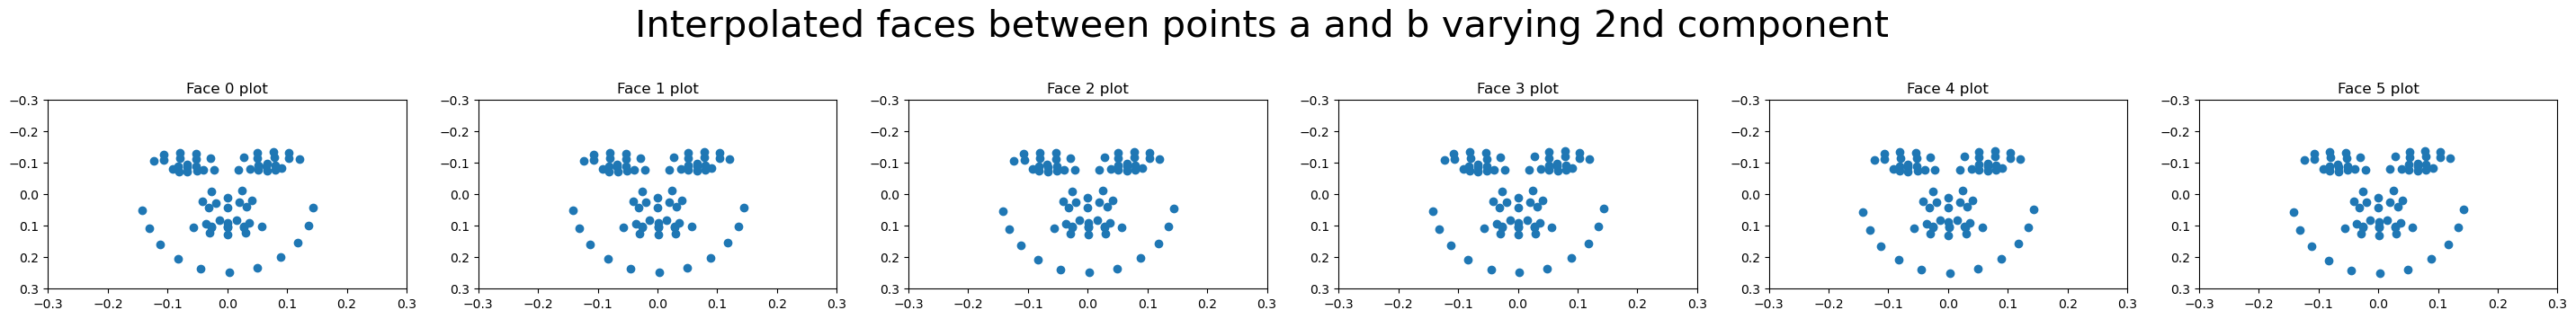

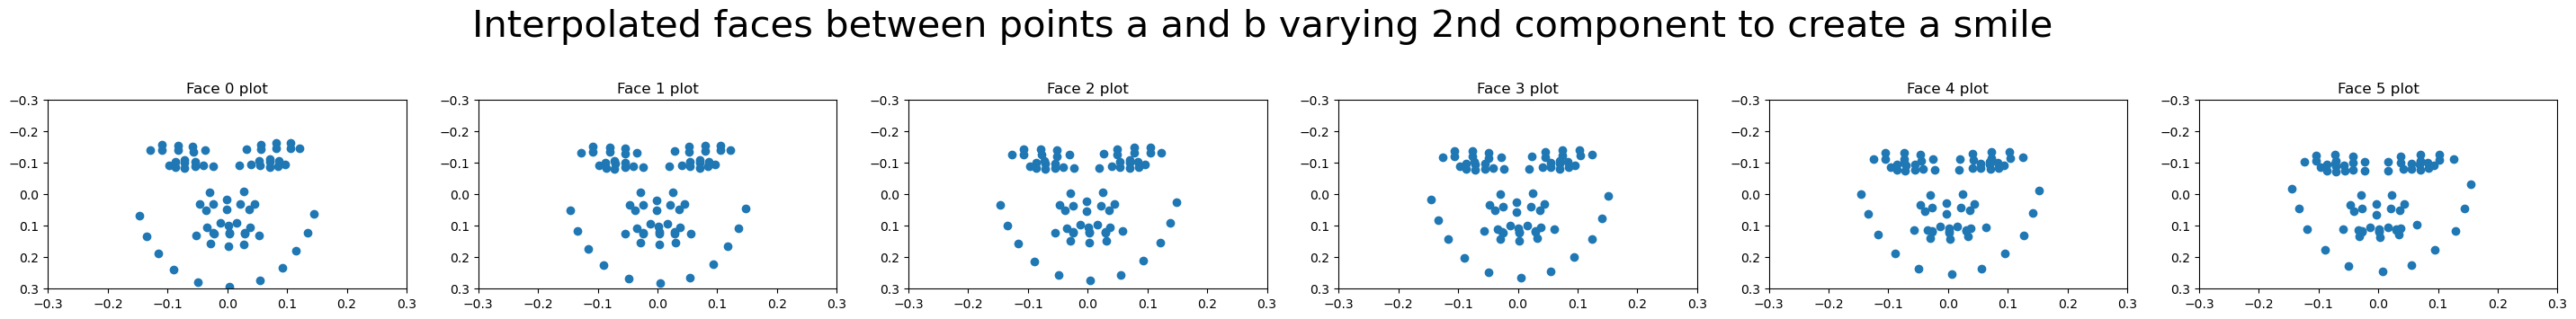

In [21]:
# write the implementation for "Interpolation between two faces" here
# 1 Select points $\mathbf{a}$ and $\mathbf{b}$ in latent space (paying attention to the Gaussian constraints) and generate the faces.

# Remember: The Gaussian constraints imply that the points should not be too far from the origin in latent space, as the latent variables are assumed to follow a standard normal distribution.
# The points should be whithin 3 standard deviations from the mean (which is 0 in this case).

a = np.array([2*np.sqrt(val[0]), -1*np.sqrt(val[1]), 2*np.sqrt(val[2]), 0, 0])  # Point a in latent space
b = np.array([-2*np.sqrt(val[0]), 2*np.sqrt(val[1]), -2*np.sqrt(val[2]), 0, 0])  # Point b in latent space
faceA = transform_from_latent_space(a, comp[:, :5], mu)
faceB = transform_from_latent_space(b, comp[:, :5], mu)
plot_face(faceA)
plt.title("Face A")
plt.show()

plot_face(faceB)
plt.title("Face B")
plt.show()

# 2 
interpolated_points = np.linspace(a, b, num=6)  # Generate 6 evenly spaced points between a and b
interpolated_faces = transform_from_latent_space(interpolated_points, comp[:, :5], mu)
plot_many_faces(interpolated_faces, "Interpolated faces between points a and b varying 1st, 2nd and 3rd components")

# 3
a = np.array([-3*val[0],0,-3*val[2],0,0])
b = np.array([3*val[0],0,3*val[2],0,0])
interpolated_points = np.linspace(a, b, num=6) 
interpolated_faces = transform_from_latent_space(interpolated_points, comp[:, :5], mu)
plot_many_faces(interpolated_faces, "Interpolated faces between points a and b varying 1st and 3rd components")

a = np.array([0,5*val[1],0,0,0])
b = np.array([0,-5*val[1],0,0,0])
interpolated_points = np.linspace(a, b, num=6) 
interpolated_faces = transform_from_latent_space(interpolated_points, comp[:, :5], mu)
plot_many_faces(interpolated_faces, "Interpolated faces between points a and b varying 2nd component")

# To generate a smile, we can try to adjust the latent variables in a way that affects the mouth region of the face.
# Based on our previous observations, we can try to vary the second principal component, as it seemed to influence the mouth shape.
a = np.array([2*np.sqrt(val[0]), -3*np.sqrt(val[1]), 0, 0, 0])  # Point a in latent space
b = np.array([2*np.sqrt(val[0]), 3*np.sqrt(val[1]), 0, 0, 0])  # Point b in latent space
interpolated_points = np.linspace(a, b, num=6) 
interpolated_faces = transform_from_latent_space(interpolated_points, comp[:, :5], mu)
plot_many_faces(interpolated_faces, "Interpolated faces between points a and b varying 2nd component to create a smile")
# OBS We also made the first component larger to make the face look a bit down to make the smile more visible.


---
**Task 8 (medium): Reflection💡**
Describe and reflect on the results obtained from this assignment, the exercises and the in-class exercises. Answer the following questions:
1. **Behaviour:** Explain why, a set of points interpolated on a line in latent space corresponds to a sample on a line in data space using $x = \Phi\mathbf{a} + \mu$. 
2. How well can a few principal components reproduce the samples? What happens with the generated data when the number of components $k$ is changed to 1,3,9, or 15?


---

In [42]:
# Write reflections here.
# Describe and reflect on the results obtained from this assignment, the exercises and the in-class exercises. Answer the following questions:
# 1. **Behaviour:** Explain why, a set of points interpolated on a line in latent space corresponds to a sample on a line in data space using x = Phi*a + mu. 
# Explanation:
# The relationship between latent space and data space is defined by the linear transformation x = Φ*a + μ, where Φ is the matrix of principal components, a is the latent variable vector, and μ is the mean vector.
# When we interpolate between two points a and b in latent space, we create a series of points that lie on the line segment connecting a and b.
# But since these points are linearly combined with the principal components and the mean vector to obtain the corresponding points in data space, the resulting points in data space will also lie on a line segment connecting the transformed points of a and b.
# This is because *linear* transformations makes sure that points that are on a line in latent space will remain on a line in data space after the transformation (otherwise it would not be linear).

# 2. How well can a few principal components reproduce the samples? What happens with the generated data when the number of components k is changed to 1,3,9, or 15?
# A few principal components can reproduce the samples reasonably well, capturing the most significant variations in the data.
# As we saw in previous calculations, using 3 components already captured a significant portion of the variance in the dataset. (and in part 1 task 3 we saw that we only need 4 components to retain 80% variance).
# As we increase the number of components k to 9 or 15, the reconstruction quality improves further, capturing finer details and nuances in the face shapes.
# However, there are diminishing returns as we add more components, as the later components capture less significant variations.
# Using too many components can also lead to overfitting, where the model captures noise in the data rather than meaningful patterns. Therefore, 9 components might be preferable compared to 15, as it balances reconstruction quality and model complexity.

## Last section - optional
This final section includes three tasks that offer valuable insights into the application of PCA, however completing this section is optional.

---
**Task 9 (medium): Eigenvalues and eigenvectors of correlation matrix _(optional)_👩‍💻💡**
1. Implement the function `get_principal_components_correlation`
 according to the comments in the cell below.
2. Use the provided code to display the eigenvalues of the correlation matrix.
3. How do the eigenvalues obtained from the covariance matrix compare to those from the correlation matrix in terms of magnitude and the variance each principal component explains? What does this reveal about the effect of feature scaling on PCA results?


---

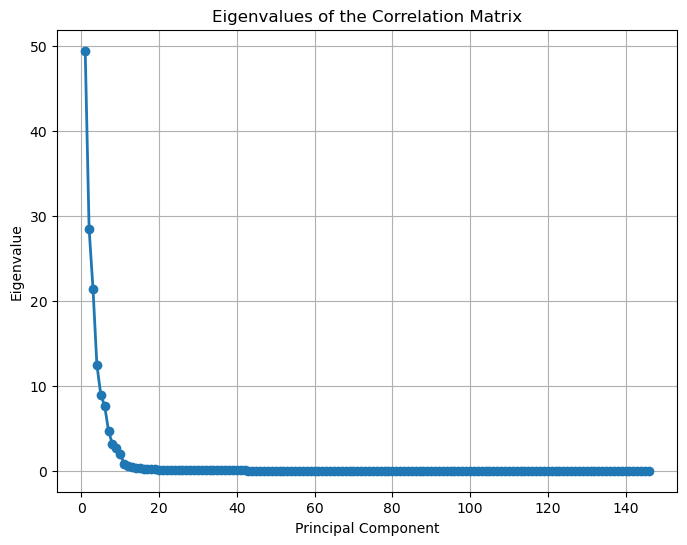

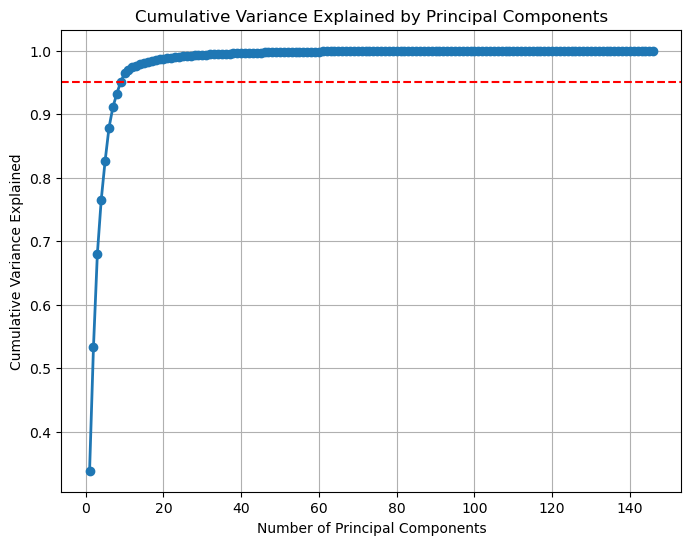

In [28]:
def get_principal_components_correlation(X):
    """Calculates principal components using the correlation matrix for X.

    Args:
        X: The dataset. An NxD array where N are the number of samples and D are
        the number of features.

    Returns:
        Tuple (components, eigenvalues, mu) where components is a DxD matrix of
        principal components, eigenvalues is a D-element vector of
        corresponding eigenvalues, and mu is a D-element array containing the mean
        vector.
    """
    # Standardize the data
    mu = np.mean(X, axis=0)
    X_std = (X - mu) / np.std(X, axis=0, ddof=1)  # Standardizing the data to have mean 0 and std 1.
    
    # Compute the correlation matrix
    corr_matrix = np.corrcoef(X_std, rowvar=False)
    # or manually:
    # D = X_std.shape[1]
    # corr_matrix = np.zeros((D, D))
    # for i in range(D):
    #     for j in range(D):
    #         # Compute the covariance between feature i and feature j
    #         cov_matrix_ij = np.cov(X_std[:, i], X_std[:, j]) # cov gives a matrix with [[var_i, cov_ij], [cov_ij, var_j]]
    #         cov_ij = cov_matrix_ij[0, 1] # extract the covariance value
    #         std_i = np.std(X_std[:, i], ddof=1) # should be 1 since we standardized
    #         std_j = np.std(X_std[:, j], ddof=1) # should be 1 since we standardized
    #         corr_matrix[i, j] = cov_ij / (std_i * std_j) # correlation formula: cov(X_i, X_j) / (std(X_i) * std(X_j))
    
    # Sort the eigenvalues and eigenvectors in descending order
    eigenvalues, eigenvectors = np.linalg.eigh(corr_matrix)
    sorted_indices = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[sorted_indices]
    eigenvectors = eigenvectors[:, sorted_indices]
    components = eigenvectors
    return (components, eigenvalues, mu)

# Use the function on the shapes data
eigenvectors_corr, eigenvalues_corr, mu_corr = get_principal_components_correlation(shapes)

# Optionally, plot the eigenvalues to see their distribution
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(eigenvalues_corr) + 1), eigenvalues_corr, 'o-', linewidth=2)
plt.title('Eigenvalues of the Correlation Matrix')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue')
plt.grid(True)
plt.show()

variance_explained = eigenvalues_corr / np.sum(eigenvalues_corr)
cumulative_variance_explained = np.cumsum(variance_explained)

# Plot cumulative variance explained
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cumulative_variance_explained) + 1),
         cumulative_variance_explained, 'o-', linewidth=2)
plt.title('Cumulative Variance Explained by Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Variance Explained')
plt.axhline(y=0.95, color='r', linestyle='--')  # Line to indicate 90% variance
plt.grid(True)
plt.show()


# 3. How do the eigenvalues obtained from the covariance matrix compare to those from the correlation matrix in terms of magnitude and the variance each principal component explains? 
# What does this reveal about the effect of feature scaling on PCA results?

# (The principal components where computed using the correlation matrix here, 
# but in the introduction to PCA (01), task 1, they were computed using the covariance matrix)

# The eigenvalues obtained from the covariance matrix and the correlation matrix can differ significantly in terms of magnitude and the variance each principal component explains.
# Eigenvalues from the covariance matrix are influenced by the scale of the original features, meaning that features with larger variances will dominate the principal components.
# In contrast, eigenvalues from the correlation matrix are standardized, meaning that each feature contributes equally to the principal components regardless of their original scale.
# Thereby, the principal components might explain variance in another direction (another combination of features) and/or of a different size, when using the correlation matrix compared to the covariance matrix.




---
**Task 10 (medium): Dimensionality reduction of features _(optional)_👩‍💻💡**
1. **Transform data:** Use $\mathbf{\Phi^{\top}}$​ to transform the data $\mathbf{x}$ into its latent-space representation $\mathbf{x'}$ (using $\mathbf{x'}= \mathbf{\Phi^{\top}}(\mathbf{x}-\mathbf{\mu})$).
2. Plot the first two  components in latent space using a scatterplot.    - What does this plot tell you about the distribution of faces?
    - Try plotting different pairs of components. Describe how each combination separates (clusters) the dataset differently.


3. **Interpolate between real faces:** Re-implement [Task 6](#interpolate) but instead of selecting 2 points in latent space, transform two real faces to latent space and interpolate between them.     - Plot the faces of the interpolated points.




---

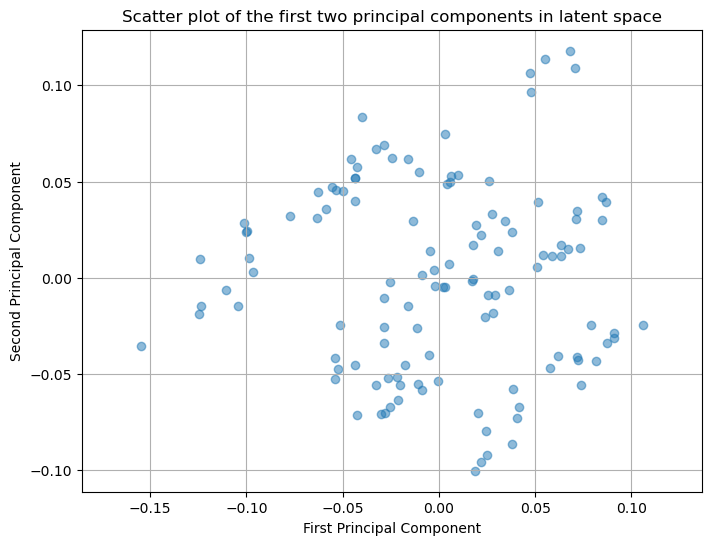

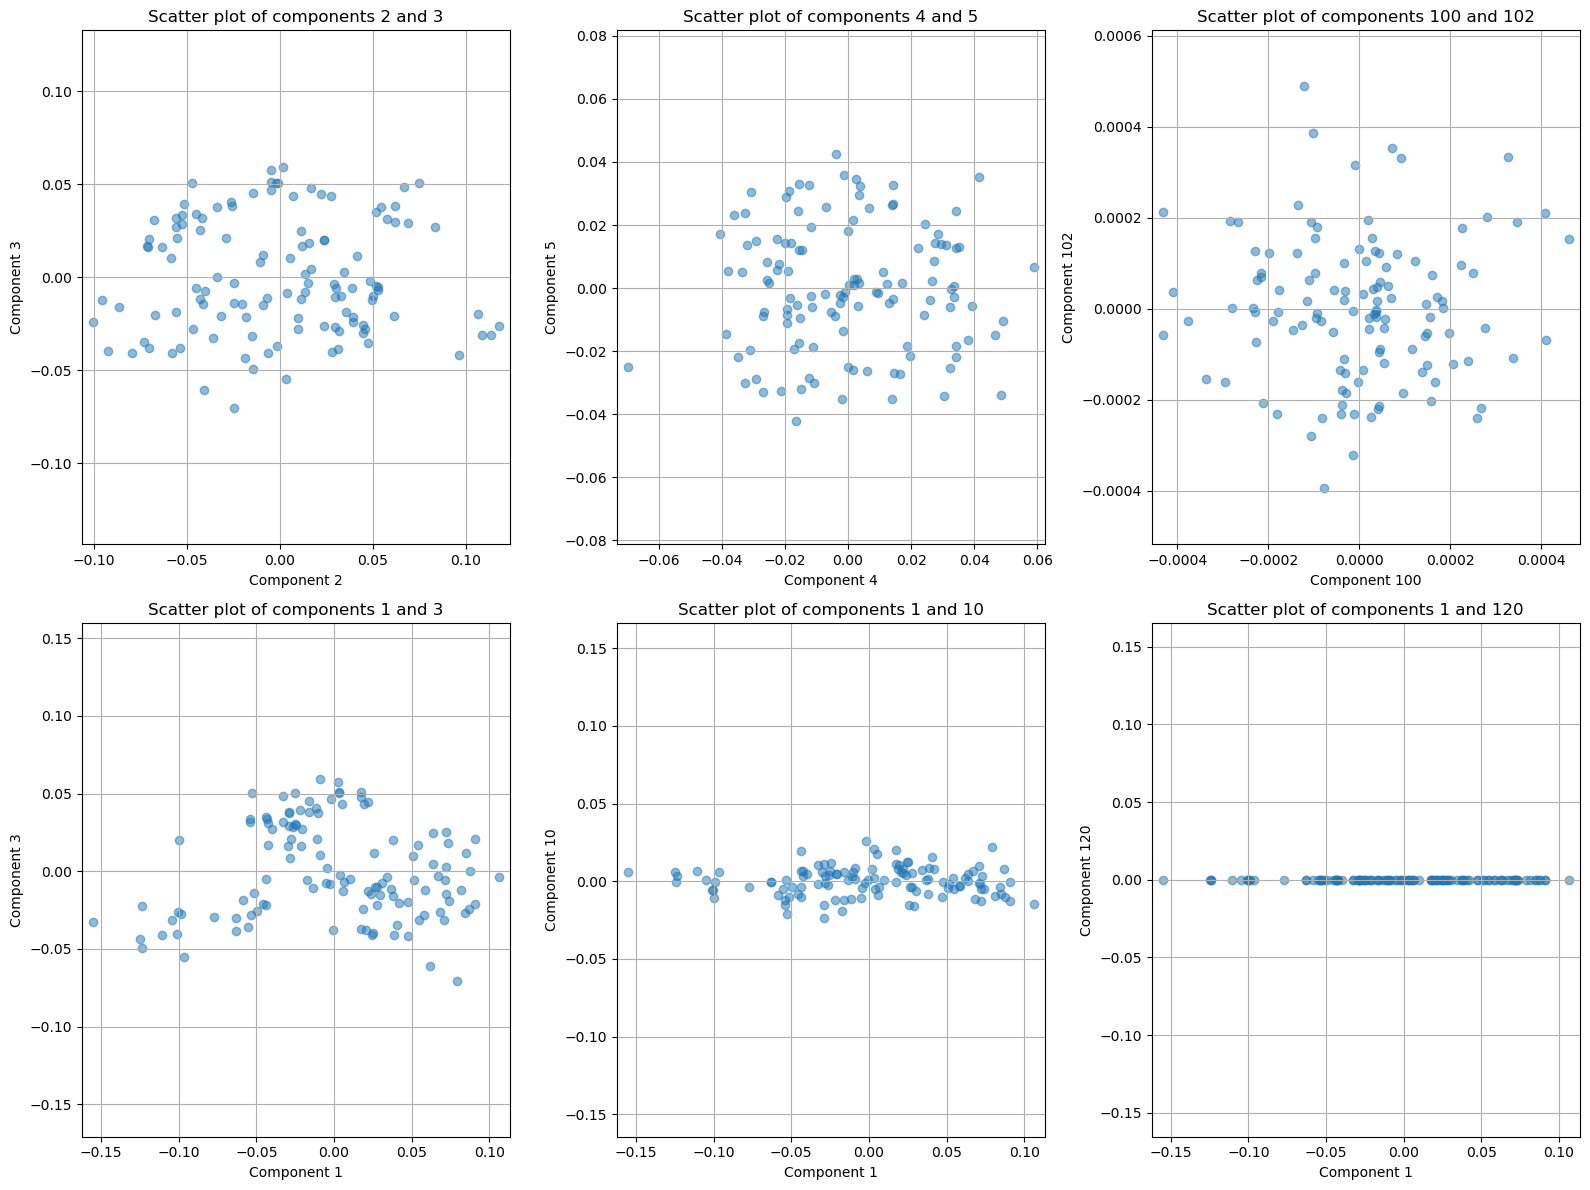

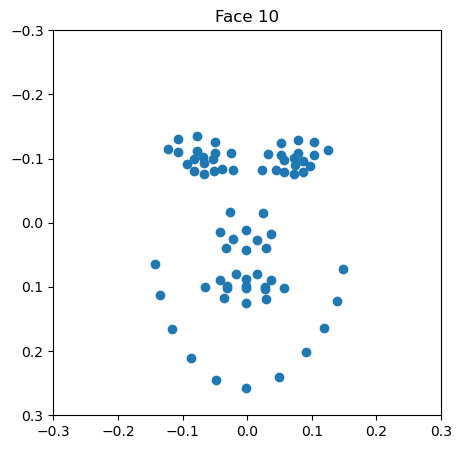

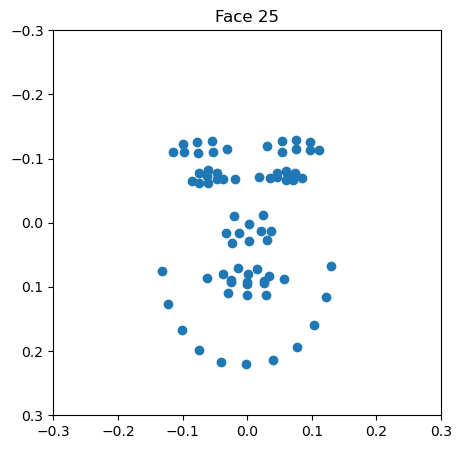

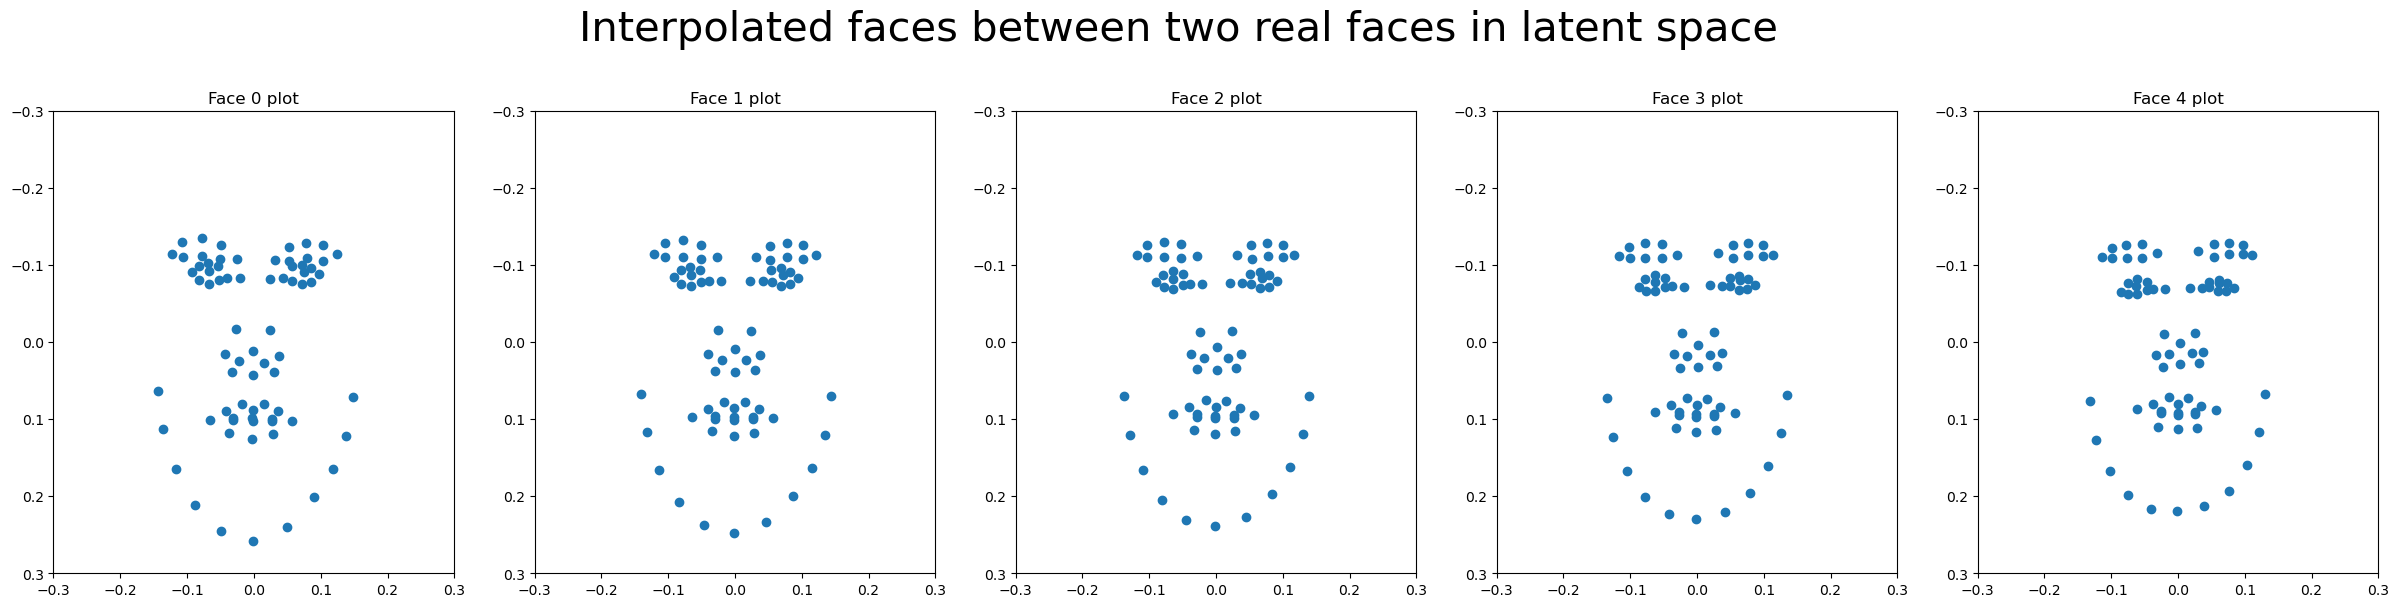

In [60]:
# Write implementation here

# 1. **Transform data:** Use $\mathbf{\Phi^{\top}}$​ to transform the data $\mathbf{x}$ into its latent-space representation $\mathbf{x'}$ (using $\mathbf{x'}= \mathbf{\Phi^{\top}}(\mathbf{x}-\mathbf{\mu})$).
latent_shapes = transform_to_latent_space(shapes, comp, mu)

# 2. Plot the first two  components in latent space using a scatterplot.    
plt.figure(figsize=(8, 6))
plt.scatter(latent_shapes[:, 0], latent_shapes[:, 1], alpha=0.5) # alpha for transparency
plt.title('Scatter plot of the first two principal components in latent space')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.grid(True)
plt.axis('equal')
plt.show()

# - What does this plot tell you about the distribution of faces?
# The scatter plot of the first two principal components in latent space reveals how the faces are distributed based on the most significant variations captured by these components.
# The points appear to be spread out well in both dimensions, although slightly more along the first component axis, indicating that there is more variance in that direction.
# - Try plotting different pairs of components. Describe how each combination separates (clusters) the dataset differently.
# The smaller the component index, the less variance in that direction, so the points will be more clustered together in the direction of the smaller component.

component_pairs = [(1, 2), (3, 4), (99, 101), (0, 2), (0, 9), (0, latent_shapes.shape[0]-1)]
plt.figure(figsize=(16, 12))
for i, (comp_x, comp_y) in enumerate(component_pairs):
    plt.subplot(2, 3, i + 1)
    plt.scatter(latent_shapes[:, comp_x], latent_shapes[:, comp_y], alpha=0.5)
    plt.title(f'Scatter plot of components {comp_x + 1} and {comp_y + 1}')
    plt.xlabel(f'Component {comp_x + 1}')
    plt.ylabel(f'Component {comp_y + 1}')
    plt.grid(True)
    plt.axis('equal') # keep aspect ratio square
plt.tight_layout()
plt.show()

# 3. **Interpolate between real faces:** 
# Re-implement [Task 6](#interpolate) but instead of selecting 2 points in latent space, transform two real faces to latent space and interpolate between them.     
# - Plot the faces of the interpolated points.
face1 = shapes[9]  # Select the 10th face
face2 = shapes[24]  # Select the 25th face

#plot face1 and face2
plot_face(face1)
plt.title("Face 10")
plt.show()
plot_face(face2)
plt.title("Face 25")
plt.show()
latent_face1 = transform_to_latent_space(face1.reshape(1, -1), comp, mu)[0]
latent_face2 = transform_to_latent_space(face2.reshape(1, -1), comp, mu)[0]
interpolated_points = np.linspace(latent_face1, latent_face2, num=5)  # Generate 5 evenly spaced points between face1 and face2 in latent space
interpolated_faces = transform_from_latent_space(interpolated_points, comp, mu)
plot_many_faces(interpolated_faces, "Interpolated faces between two real faces in latent space")

Describe the different scatter plots of component combinations

---
**Task 11 (medium): Out of distribution generation _(optional)_👩‍💻💡**
1. **Extreme values:** What happens if you select values outside the suggested range. Explain why this happens.


---

In [0]:
# Write implementation and reflections here
# 1. **Extreme values:** What happens if you select values outside the suggested range. Explain why this happens.
# Selecting values outside the suggested range of ±3 standard deviations in latent space can lead to the generation of unrealistic or distorted faces when transformed back to data space.
# This occurs because the PCA model is trained on the original dataset, which is assumed to follow a Gaussian distribution in latent space.
# Points that lie far from the mean (beyond ±3 standard deviations) are less likely to represent valid variations of the original data, leading to extrapolation beyond the learned distribution.
# As a result, the generated faces may exhibit exaggerated features or artifacts that do not correspond to any real faces in the dataset.
# In the plot above, where we interpolated between two real faces, the intermediate faces appear realistic because they lie within the range of variations captured by the PCA model.